In [6]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    desc_add="clean",
)




EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


In [18]:
from SleepMReye.plotting import plot_surface_searchlight
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation
from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
import nibabel as nib


# --- Run searchlight and plot ---
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)
corr_maps = {}
window_size = 3 


[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2230, Median: 2164, Min: 799, Max: 4393
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2272, Median: 2208, Min: 865, Max: 4762


In [22]:
from SleepMReye.plotting import plot_surface_searchlight
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation
from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
import nibabel as nib

threshold = 0.3
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)

for state_1 in ("", "_W", "_S"):
    print(f"=== Head Motion Controls Raw vs Clean for {state_1} ===")
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/head_motion_controls")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"combined_correlation_map"
    # data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="raw-original-sleep-incl-nrem3-flame")    
    data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="conv-fd-sleep-flame")    
    data_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="clean-with-fd-clamped-original-sleep-incl-nrem3-flame")

    corr_maps, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=neighborhoods
    )

    # for hemi in ("left", "right"):
    #     c = corr_maps[hemi]
    #     mask = np.abs(c) > 1e-6
    #     print(f"  {hemi}: mean r={c[mask].mean():.3f}, "
    #           f">0.3: {(c > 0.3).sum() / len(c)}, "
    #           f"<-0.3: {(c < -0.3).sum() / len(c)}")

    # plot_surface_searchlight(
    #     corr_maps,
    #     surf_mesh=surf_mesh,
    #     inflate=True,
    #     title=f"Searchlight r: {state_1} mreyemove vs eog ({radius_mm}mm geodesic)",
    #     output_file=f"{output_path}.png"
    #     # threshold=0.3,
    # )
    # 

=== Head Motion Controls Raw vs Clean for  ===
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163838
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.955693930387497
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9595390260219574
median r: 0.9578022360801697
=== Head Motion Controls Raw vs Clean for _W ===
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163828
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9524404406547546
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 100.0%
r_valid <= 

In [4]:
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods
import os
from SUITPy import flatmap

radius_mm = 29.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)


Building geodesic neighborhoods (radius=29.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 827, Median: 845, Min: 1, Max: 1336


=== Head Motion Controls Raw vs Clean for  ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9605144262313843
=== Head Motion Controls Raw vs Clean for _W ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9505230188369751
=== Head Motion Controls Raw vs Clean for _S ===
n vertices = 28935
r_valid >=  0.3: 99.7%
r_valid <= -0.3: 0.0%
n valid vertices = 28834
r_valid >=  0.3: 100.0%
r_valid <= -0.3: 0.0%
median r: 0.9703599512577057


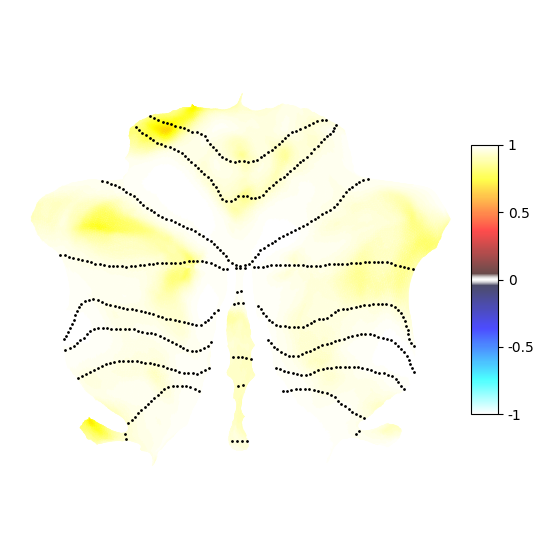

In [17]:
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap


for state_1 in ("", "_W", "_S"):
    print(f"=== Head Motion Controls Raw vs Clean for {state_1} ===")
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/head_motion_controls/cerebellum")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"combined_correlation_map"
    # vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="raw-original-sleep-cer-cov-flame")    
    vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="conv-fd-sleep-cer-cov-flame")    
    vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="clean-original-sleep-incl-nrem3-cer-cov-flame")

    

    # title = f"searchlight_surface_hmc_{state_1}_{state_2}_{radius_mm}"
    

# vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_1}", desc_add=desc_add)
# vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_2}", desc_add=desc_add)

# vol_a,_ = mrio.load_FLAME_result(contrast=f"eog_{state_1}", desc_add=desc_add)
# vol_b,_ = mrio.load_FLAME_result(contrast=f"eog_{state_2}", desc_add=desc_add)

    
    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')
    
    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=neighbourhoods,
        min_vertices=10,
    )

ax = flatmap.plot(data=results, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-1.0, 1.0])
# ax.set_title(title)
# 
# output_path = output_dir / f"{title}.png"
# 
# ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")



In [53]:
import numpy as np
import nibabel as nib 

res_raw, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add="raw-original-sleep-incl-nrem3-flame")
res_clean, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add="clean-with-fd-clamped-original-sleep-incl-nrem3-flame")


np.average(np.abs(res_clean.t_stat.get_fdata())) / np.average(np.abs(res_raw.t_stat.get_fdata()))
# 
# raw_cope = res_raw.cope_4d.get_fdata()
# raw_var = res_raw.var_4d.get_fdata()
# 
# 
# z_raw = raw_cope / np.sqrt(raw_var)
# mask  = np.abs(z_raw) > 2
# mask.reshape((-1, raw_cope.shape[-1]))
# 
# raw_cope = raw_cope[mask]
# raw_var = raw_var[mask]
# 
# clean_cope = res_clean.cope_4d.get_fdata()[mask]
# clean_var = res_clean.var_4d.get_fdata()[mask]
# 
# x, sx = raw_cope,   np.sqrt(raw_var)
# y, sy = clean_cope, np.sqrt(clean_var)
# 
# w = 1.0 / (raw_var + clean_var)
# 
# np.mean(np.average(np.abs(y), weights=w, axis=0) / np.average(np.abs(x), weights=w, axis=0))
# ratio = np.average(np.abs(y), weights=w, axis=1) / np.average(np.abs(x), weights=w, axis=0)

# np.corrcoef(ratio)



0.9259916681862802

In [45]:
np.mean(np.average(np.abs(y),weights=w, axis=0) / np.average(np.abs(x),weights=w, axis=0))

0.9523883489870226